In [1]:
import os
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [2]:
#root_folder = 'demo-images/4-light/dome/'
root_folder = 'demo-images/unity captures/12/'

In [3]:
def flatten_image(image):
    return (image/255).flatten()

In [11]:
L = []
images = []
for file in os.listdir(root_folder):
    #print(file)
    file_dir = root_folder + file
#     if '.txt' in file:
#         L = np.loadtxt(file_dir).T
#     else:
#         images.append(cv2.imread(file_dir, cv2.IMREAD_GRAYSCALE))
    image = cv2.imread(file_dir, cv2.IMREAD_GRAYSCALE)
    images.append(image)
    light_coords = file_dir.split('(')[1].split(')')[0].split(',')
    light_xyz = [float(c) for c in light_coords]
    L.append(light_xyz)

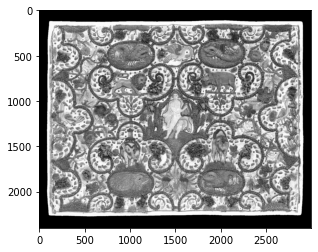

In [12]:
plt.imshow(cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB))

In [13]:
cv2.imwrite('tmp3.png', images[0])

True

In [7]:
images[0][1212, 730]

120

In [14]:
L = np.array(L)

In [18]:
L

array([[ 0.5 ,  0.71,  0.5 ],
       [ 0.71,  0.  ,  0.71],
       [ 0.5 , -0.71,  0.5 ],
       [ 0.  ,  1.  ,  0.  ],
       [ 0.  , -1.  ,  0.  ],
       [-0.5 , -0.71, -0.5 ],
       [-0.71,  0.  , -0.71],
       [-0.5 ,  0.71, -0.5 ],
       [-0.71, -0.71,  0.  ],
       [-1.  ,  0.  ,  0.  ],
       [-0.71,  0.71,  0.  ],
       [-0.5 , -0.71,  0.5 ],
       [-0.71,  0.  ,  0.71],
       [-0.5 ,  0.71,  0.5 ],
       [ 0.  , -0.71,  0.71],
       [ 0.  ,  0.  ,  1.  ],
       [ 0.  ,  0.71,  0.71],
       [ 0.71,  0.71,  0.  ],
       [ 1.  ,  0.  ,  0.  ],
       [ 0.71, -0.71,  0.  ],
       [ 0.5 ,  0.71, -0.5 ],
       [ 0.71,  0.  , -0.71],
       [ 0.5 , -0.71, -0.5 ],
       [ 0.  ,  0.71, -0.71],
       [ 0.  ,  0.  , -1.  ],
       [ 0.  , -0.71, -0.71]])

In [7]:
L = L.T

In [16]:
L.shape

(26, 3)

In [17]:
np.linalg.matrix_rank(L)

3

In [11]:
def ps_basic_ols(images, L):
    """
    A simple implementation of Photometric Stereo using Ordinary Least Squares. This is compatible with
    3 or more light sources, provided the number of images matches the number of lights.

    Images should be an `n` element list of single-channel greyscale images.
    L is a 3xn numpy array of column vectors for the light direction vectors
    """
    
    original_size = images[0].shape[:2]
    
    # Normalise all images and convert to row vectors (each image is one row)
    images = np.vstack(map(flatten_image, images))
    
    # Make sure that lighting vectors are normalised
    L = L / np.linalg.norm(L, ord=2, axis=1, keepdims=True)

    # Solve for G = N'*rho using ordinary least squares
    # (L^T L) \ L^T
    norm_sln = np.linalg.pinv(L.T.dot(L)).dot(L.T)
    
    print('shapes')
    print(norm_sln.shape)
    print(images.shape)
    
    # For a single pixel (3x1 column) we can trivially calculate G: norm_sum * px
    # norm_sln is 3x3, images is 3xn (where n i num pixels)
    # It's slow to iterate this, but the einsum method lets us broadcast the multiplication over the array
    G = np.einsum("ij,il", norm_sln, images)
    #G = np.einsum("ij,jl", norm_sln, images)
    
    # The albedo is just the column-wise L2 norm (magnitude) of G...
    rho = np.linalg.norm(G, axis=0)

    # The normal map is simply each column of G divided the equivalent column in the albedo
    N = np.divide(G, np.vstack([rho] * 3))

    # Reshape back to image
    rho = rho.reshape(original_size)

    # We need to transpose the normal list before we reshape
    N = N.T.reshape(original_size[0], original_size[1], 3)

    return N, rho

In [12]:
N, rho = ps_basic_ols(images, L)

<ipython-input-11-726ece5c463e>:13: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  images = np.vstack(map(flatten_image, images))


shapes
(26, 3)
(26, 7200000)


<ipython-input-11-726ece5c463e>:36: RuntimeWarning: invalid value encountered in true_divide
  N = np.divide(G, np.vstack([rho] * 3))


In [26]:
# Values in N range from -1...1, we need them in 0...1, so we'll quickly remap it
N_display = (N + 1) / 2

In [30]:
N_display[np.isnan(N_display)] = 0

In [31]:
N_display.shape

(2400, 3000, 3)

In [35]:
n_new = N_display
n_new[:, ]

In [34]:
N_display[:]

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]])

<ipython-input-36-f1ceeca0c13b>:1: MatplotlibDeprecationWarning: Passing non-integers as three-element position specification is deprecated since 3.3 and will be removed two minor releases later.
  plt.subplot('121')
<ipython-input-36-f1ceeca0c13b>:3: MatplotlibDeprecationWarning: Passing non-integers as three-element position specification is deprecated since 3.3 and will be removed two minor releases later.
  plt.subplot('122')


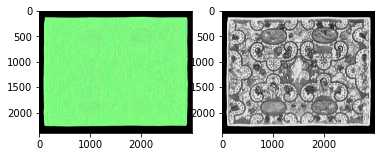

In [36]:
plt.subplot('121')
plt.imshow(n_new)
plt.subplot('122')
plt.imshow(255 * rho, cmap='gray')
plt.show()

In [22]:
type(N_display)

numpy.ndarray

In [46]:
cv2.imwrite('green_normal_v3.png', N_display*255)

True

In [70]:
type(N)

numpy.ndarray